In [65]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

Дифференцирование

In [2]:
def grad(outputs, inputs):
    """Computes the partial derivative of 
    an output with respect to an input.
    Args:
        outputs: (N, 1) tensor - surfaces
        inputs: (N, D) tensor - ts
    """
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )

Уже продифференцируемое уравнение, для сравнения и генерации данных:

In [3]:
def grinding_kinetics(time, Smax, S0, k):
    S = Smax + (S0 - Smax) * np.exp(-k * time)
    return S

Text(0.5, 0, 'Время, с')

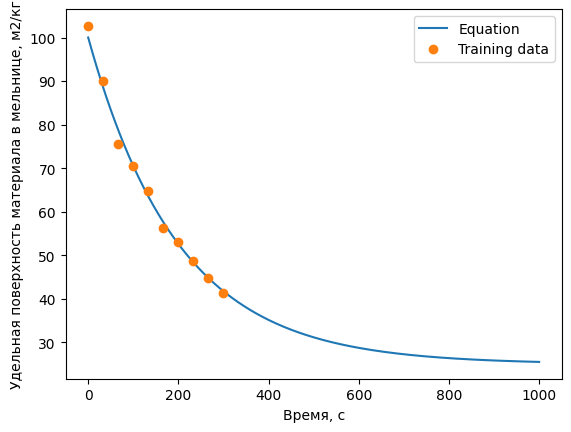

In [4]:
np.random.seed(10)
# Ниже параметры неверные, но взяты для примера
Smax = 25
S0 = 100
k = 0.005
times = np.linspace(0, 1000, 1000) # 1000 чисел от 0 до 1000
# eq = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)
# surfaces = eq(times)
surfaces = grinding_kinetics(time=times,Smax=Smax, S0=S0, k=k)

# Make training data
t = np.linspace(0, 300, 10) # 10 чисел времени от 0 до 300 
S = grinding_kinetics(time=t,Smax=Smax, S0=S0, k=k) +  2 * np.random.randn(10)

plt.plot(times, surfaces)
plt.plot(t, S, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

# Архитектура модели

input_dim — размерность входных данных;<br>
output_dim — размерность выходных данных;<br>
n_units — число нейронов в скрытых слоях (по умолчанию 100);<br>
epochs — количество эпох обучения (1000);<br>
loss — основная функция потерь (MSE по умолчанию);<br>
lr — скорость обучения (0.001);<br>
loss2 — дополнительная функция потерь (физическая);<br>
loss2_weight — вес второй потери (0.5).<br>
k - доп.дифференцируемый параметр

Структура:

4 скрытых слоя по 100 нейронов;
После каждого линейного слоя — ReLU (функция активации);
Выходной слой — линейный (без активации).

In [86]:
import torch.nn as nn
import torch.optim as optim
# import torch.utils.data as thdat

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Конвертация массив NumPy в тензор PyTorch
def np_to_th(x):
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)


class Pinn(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.5,
        k = 0.005
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units
        # self.k = nn.Parameter(data=torch.tensor([0.])) # Начальное значение 0, обучаемый параметр 
        self.k = k

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.ReLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)

        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())
            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.2f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()


LOSS

In [87]:
def physics_loss(model: torch.nn.Module):
    ts = torch.linspace(0, 1000, steps=1000,).view(-1,1).requires_grad_(True).to(DEVICE)
    surfaces = model(ts)
    dS = grad(surfaces, ts)[0]
    pde = model.k * (Smax - surfaces) - dS
    
    return torch.mean(pde**2)



добавить автодиф по z

Epoch 0/40000, loss: 4427.07
Epoch 4000/40000, loss: 2513.23
Epoch 8000/40000, loss: 2116.87
Epoch 12000/40000, loss: 503.24
Epoch 16000/40000, loss: 2.18
Epoch 20000/40000, loss: 1.58
Epoch 24000/40000, loss: 0.65
Epoch 28000/40000, loss: 0.39
Epoch 32000/40000, loss: 0.34
Epoch 36000/40000, loss: 0.33


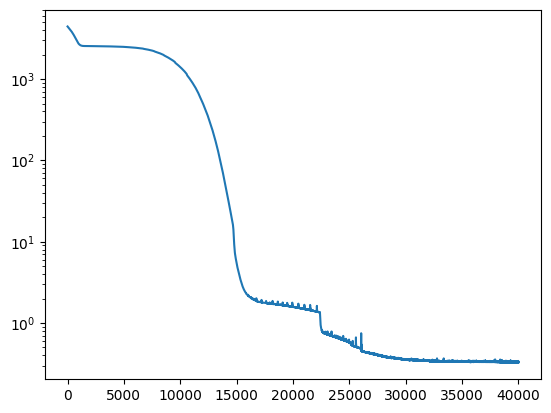

In [88]:
pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6).to(DEVICE)

losses = pinn.fit(t, S)
plt.plot(losses)
plt.yscale('log')

0.005


Text(0.5, 0, 'Время, с')

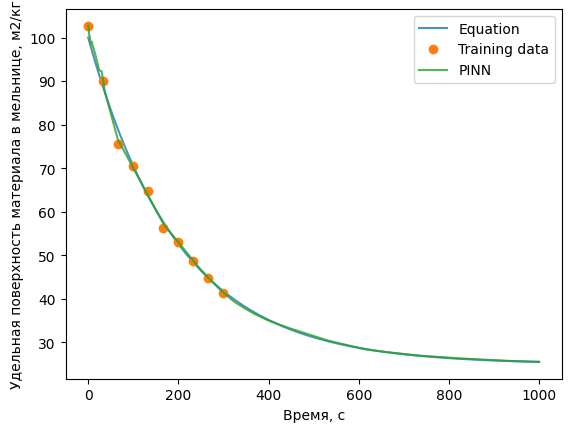

In [89]:
preds = pinn.predict(times)
print(pinn.k)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

Epoch 0/40000, loss: 4497.24
Epoch 4000/40000, loss: 2524.55
Epoch 8000/40000, loss: 2282.15
Epoch 12000/40000, loss: 673.39
Epoch 16000/40000, loss: 4.55
Epoch 20000/40000, loss: 1.04
Epoch 24000/40000, loss: 0.76
Epoch 28000/40000, loss: 0.52
Epoch 32000/40000, loss: 0.38
Epoch 36000/40000, loss: 0.36
0.0
Epoch 0/40000, loss: 4226.46
Epoch 4000/40000, loss: 2498.66
Epoch 8000/40000, loss: 2080.39
Epoch 12000/40000, loss: 278.53
Epoch 16000/40000, loss: 2.51
Epoch 20000/40000, loss: 1.81
Epoch 24000/40000, loss: 0.93
Epoch 28000/40000, loss: 0.57
Epoch 32000/40000, loss: 0.40
Epoch 36000/40000, loss: 0.34
0.001
Epoch 0/40000, loss: 4455.00
Epoch 4000/40000, loss: 2522.55
Epoch 8000/40000, loss: 2215.04
Epoch 12000/40000, loss: 501.59
Epoch 16000/40000, loss: 5.95
Epoch 20000/40000, loss: 0.51
Epoch 24000/40000, loss: 0.40
Epoch 28000/40000, loss: 0.33
Epoch 32000/40000, loss: 0.29
Epoch 36000/40000, loss: 0.28
0.002
Epoch 0/40000, loss: 4127.65
Epoch 4000/40000, loss: 2501.95
Epoch 80

KeyboardInterrupt: 

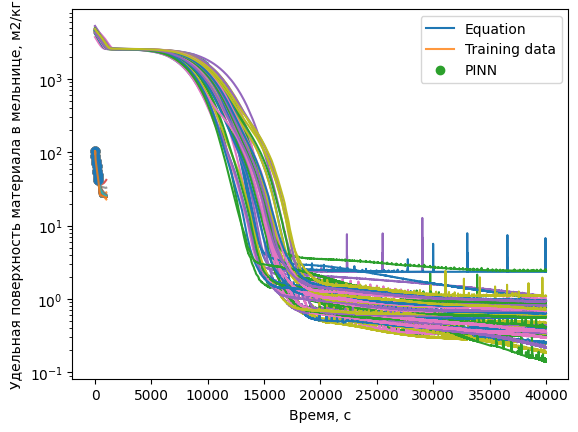

In [34]:
mse = []
ks = []

for i in np.arange(0, 1, 0.001):
    pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6, k=i).to(DEVICE)

    losses = pinn.fit(t, S)
    l.append(min(losses))
    ks.append(i)
    plt.plot(losses)
    plt.yscale('log')

    preds = pinn.predict(times)
    mse_o = np.mean((preds - surfaces)**2)
    mse.append(mse_o)
    print(pinn.k)

    plt.plot(times, surfaces, alpha=0.8)
    plt.plot(t, S, 'o')
    plt.plot(times, preds, alpha=0.8)
    plt.legend(labels=['Equation','Training data', 'PINN'])
    plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
    plt.xlabel('Время, с')

for z, m in zip(mse, ks):
    print(f'При k = {m} mse = {z}')

Epoch 0/40000, loss: 4463.10
Epoch 4000/40000, loss: 2512.10
Epoch 8000/40000, loss: 2187.50
Epoch 12000/40000, loss: 397.59
Epoch 16000/40000, loss: 4.24
Epoch 20000/40000, loss: 2.51
Epoch 24000/40000, loss: 1.49
Epoch 28000/40000, loss: 0.59
Epoch 32000/40000, loss: 0.36
Epoch 36000/40000, loss: 0.32


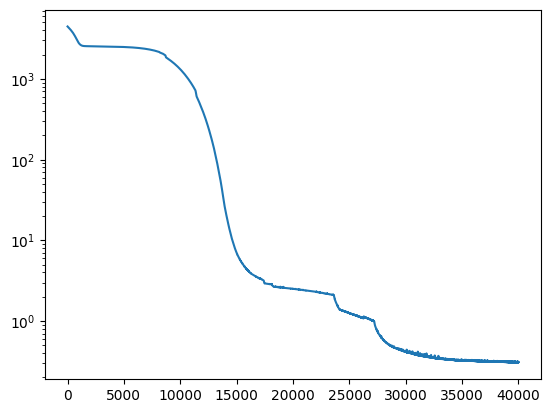

In [62]:
pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6, k=0.005).to(DEVICE)

losses = pinn.fit(t, S)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Время, с')

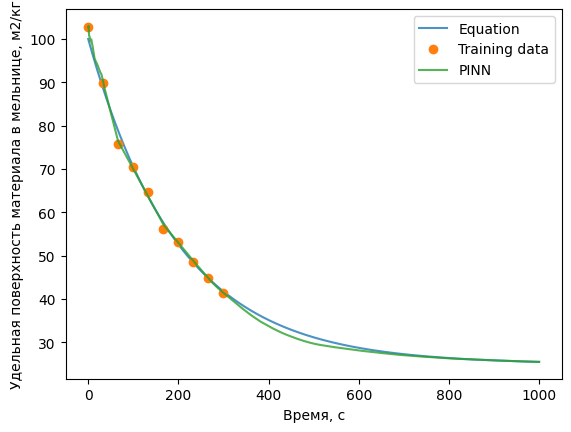

In [63]:
preds = pinn.predict(times)

plt.plot(times, surfaces, alpha=0.8)
plt.plot(t, S, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
plt.xlabel('Время, с')

In [66]:
r2 = r2_score(surfaces, preds)
r2

0.99801977368564

При k = 0.0 mse = -3.4731701772535777
При k = 0.001 mse = -7.534986582980636
При k = 0.002 mse = -7.094861589449751
При k = 0.003 mse = -3.2479694904751195
При k = 0.004 mse = -2.685494451668258
При k = 0.005 mse = -5.041167079912498
При k = 0.006 mse = -6.175486127433055
При k = 0.007 mse = -5.418502909090362
При k = 0.008 mse = -3.705776624417221
При k = 0.009000000000000001 mse = -3.3586916155469613
При k = 0.01 mse = -5.204251000617588
При k = 0.011 mse = -4.136218193967365
При k = 0.012 mse = -4.709363461435313
При k = 0.013000000000000001 mse = -5.360014844901488
При k = 0.014 mse = -5.746778510178586
При k = 0.015 mse = -5.00777932690292
При k = 0.016 mse = -7.75908381020624
При k = 0.017 mse = -5.659778589786488
При k = 0.018000000000000002 mse = -5.667400521625529
При k = 0.019 mse = -5.026875731080273
При k = 0.02 mse = -5.717258042878237
При k = 0.021 mse = -4.6409988541767895
При k = 0.022 mse = -7.4305752037304345
При k = 0.023 mse = -4.670078745003843
При k = 0.024 mse = 

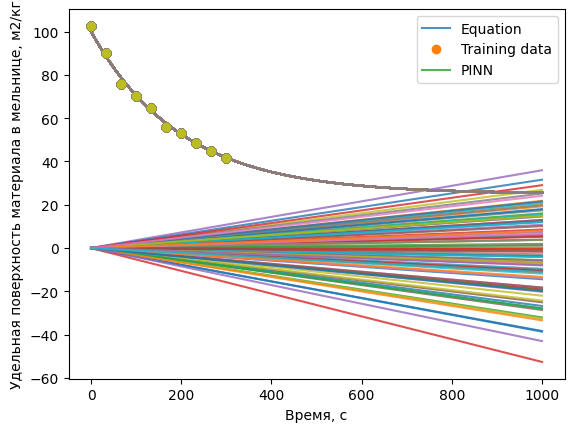

In [71]:
r2s = []
ks = []
for i in np.arange(0, 0.1, 0.001):

    pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=20000, lr= 5e-6, k=i).to(DEVICE)
    
    preds = pinn.predict(times)
    r2 = r2_score(surfaces, preds)
    r2s.append(r2)
    ks.append(i)
    plt.plot(times, surfaces, alpha=0.8)
    plt.plot(t, S, 'o')
    plt.plot(times, preds, alpha=0.8)
    plt.legend(labels=['Equation','Training data', 'PINN'])
    plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
    plt.xlabel('Время, с')

for z, m in zip(r2s, ks):
    print(f'При k = {m} mse = {z}')

Epoch 0/20000, loss: 4597.46
Epoch 2000/20000, loss: 2550.05
Epoch 4000/20000, loss: 2516.31
Epoch 6000/20000, loss: 2433.53
Epoch 8000/20000, loss: 2198.18
Epoch 10000/20000, loss: 1206.64
Epoch 12000/20000, loss: 409.12
Epoch 14000/20000, loss: 30.35
Epoch 16000/20000, loss: 2.12
Epoch 18000/20000, loss: 1.28
Epoch 0/20000, loss: 4450.67
Epoch 2000/20000, loss: 2539.46
Epoch 4000/20000, loss: 2500.14
Epoch 6000/20000, loss: 2400.17
Epoch 8000/20000, loss: 2088.68
Epoch 10000/20000, loss: 1088.83
Epoch 12000/20000, loss: 317.97
Epoch 14000/20000, loss: 26.74
Epoch 16000/20000, loss: 2.06
Epoch 18000/20000, loss: 0.71
Epoch 0/20000, loss: 4489.27
Epoch 2000/20000, loss: 2554.15
Epoch 4000/20000, loss: 2515.94
Epoch 6000/20000, loss: 2414.26
Epoch 8000/20000, loss: 2117.06
Epoch 10000/20000, loss: 1342.70
Epoch 12000/20000, loss: 479.22
Epoch 14000/20000, loss: 54.60
Epoch 16000/20000, loss: 3.87
Epoch 18000/20000, loss: 3.03
Epoch 0/20000, loss: 4373.15
Epoch 2000/20000, loss: 2541.56


KeyboardInterrupt: 

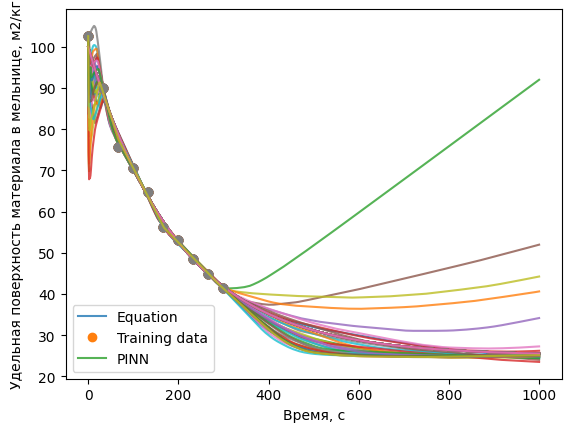

In [67]:
r2s = []
ks = []
for i in np.arange(0, 0.1, 0.001):

    pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=20000, lr= 5e-6, k=i).to(DEVICE)
    losses = pinn.fit(t, S)
    
    preds = pinn.predict(times)
    r2 = r2_score(surfaces, preds)
    r2s.append(r2)
    ks.append(i)
    plt.plot(times, surfaces, alpha=0.8)
    plt.plot(t, S, 'o')
    plt.plot(times, preds, alpha=0.8)
    plt.legend(labels=['Equation','Training data', 'PINN'])
    plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
    plt.xlabel('Время, с')

for z, m in zip(r2s, ks):
    print(f'При k = {m} mse = {z}')

In [69]:
for z, m in zip(r2s, ks):
    print(f'При k = {m} r2 = {z}')

При k = 0.0 r2 = -2.2403152157286987
При k = 0.001 r2 = 0.483428703407483
При k = 0.002 r2 = 0.7007266814773625
При k = 0.003 r2 = 0.8221174828897028
При k = 0.004 r2 = 0.9604813290631056
При k = 0.005 r2 = 0.9984560114383295
При k = 0.006 r2 = 0.994203482742483
При k = 0.007 r2 = 0.9949993068195024
При k = 0.008 r2 = 0.994860184290199
При k = 0.009000000000000001 r2 = 0.997469210682757
При k = 0.01 r2 = 0.9916969561596543
При k = 0.011 r2 = 0.9891315656828099
При k = 0.012 r2 = 0.97413812873525
При k = 0.013000000000000001 r2 = 0.9810564607727565
При k = 0.014 r2 = 0.9921624061520377
При k = 0.015 r2 = 0.9894308963797516
При k = 0.016 r2 = 0.9793638703893404
При k = 0.017 r2 = 0.9647181554742227
При k = 0.018000000000000002 r2 = 0.9867027240244084
При k = 0.019 r2 = 0.9882063101063114
При k = 0.02 r2 = 0.9884813115711099
При k = 0.021 r2 = 0.9850841218015977
При k = 0.022 r2 = 0.9824376986969372
При k = 0.023 r2 = 0.9777372247001532
При k = 0.024 r2 = 0.9910075173885063
При k = 0.025 

In [70]:
max(r2s)

0.9984560114383295

Epoch 0/40000, loss: 4355.83
Epoch 4000/40000, loss: 2500.26
Epoch 8000/40000, loss: 1711.22
Epoch 12000/40000, loss: 134.63
Epoch 16000/40000, loss: 1.07
Epoch 20000/40000, loss: 0.51
Epoch 24000/40000, loss: 0.40
Epoch 28000/40000, loss: 0.37
Epoch 32000/40000, loss: 0.36
Epoch 36000/40000, loss: 0.35
0.0
Epoch 0/40000, loss: 4710.82
Epoch 4000/40000, loss: 2659.30
Epoch 8000/40000, loss: 2083.61
Epoch 12000/40000, loss: 445.66
Epoch 16000/40000, loss: 33.94
Epoch 20000/40000, loss: 7.49
Epoch 24000/40000, loss: 6.73
Epoch 28000/40000, loss: 6.41
Epoch 32000/40000, loss: 6.36
Epoch 36000/40000, loss: 6.31
0.1
Epoch 0/40000, loss: 4633.35
Epoch 4000/40000, loss: 2953.62
Epoch 8000/40000, loss: 2394.70
Epoch 12000/40000, loss: 504.98
Epoch 16000/40000, loss: 36.53
Epoch 20000/40000, loss: 27.11
Epoch 24000/40000, loss: 26.19
Epoch 28000/40000, loss: 25.11
Epoch 32000/40000, loss: 23.95
Epoch 36000/40000, loss: 22.78
0.2
Epoch 0/40000, loss: 5208.10
Epoch 4000/40000, loss: 3139.70
Epoch

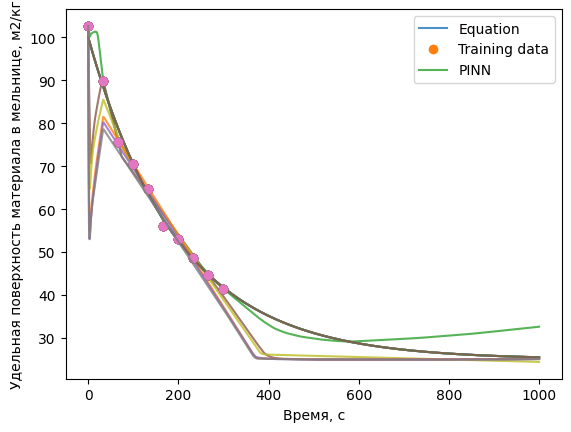

In [37]:
mse = []
ks = []

for i in np.arange(0, 0.6, 0.1):
    pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6, k=i).to(DEVICE)

    losses = pinn.fit(t, S)
    l.append(min(losses))
    ks.append(i)
    # plt.plot(losses)
    # plt.yscale('log')

    preds = pinn.predict(times)
    mse_o = np.mean((preds - surfaces)**2)
    mse.append(mse_o)
    print(pinn.k)

    plt.plot(times, surfaces, alpha=0.8)
    plt.plot(t, S, 'o')
    plt.plot(times, preds, alpha=0.8)
    plt.legend(labels=['Equation','Training data', 'PINN'])
    plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
    plt.xlabel('Время, с')

for z, m in zip(mse, ks):
    print(f'При k = {m} mse = {z}')

Epoch 0/40000, loss: 4305.73
Epoch 4000/40000, loss: 3517.51
Epoch 8000/40000, loss: 1828.44
Epoch 12000/40000, loss: 346.36
Epoch 16000/40000, loss: 135.25
Epoch 20000/40000, loss: 117.71
Epoch 24000/40000, loss: 115.20
Epoch 28000/40000, loss: 112.50
Epoch 32000/40000, loss: 111.19
Epoch 36000/40000, loss: 109.80
0.5
Epoch 0/40000, loss: 4912.51
Epoch 4000/40000, loss: 3681.64
Epoch 8000/40000, loss: 2402.81
Epoch 12000/40000, loss: 402.05
Epoch 16000/40000, loss: 186.05
Epoch 20000/40000, loss: 164.71
Epoch 24000/40000, loss: 160.83
Epoch 28000/40000, loss: 159.13
Epoch 32000/40000, loss: 157.34
Epoch 36000/40000, loss: 155.73
0.6
Epoch 0/40000, loss: 4546.94
Epoch 4000/40000, loss: 3759.12
Epoch 8000/40000, loss: 2409.58
Epoch 12000/40000, loss: 628.74
Epoch 16000/40000, loss: 263.18
Epoch 20000/40000, loss: 203.88
Epoch 24000/40000, loss: 198.93
Epoch 28000/40000, loss: 195.40
Epoch 32000/40000, loss: 192.90
Epoch 36000/40000, loss: 191.06
0.7
Epoch 0/40000, loss: 4910.40
Epoch 40

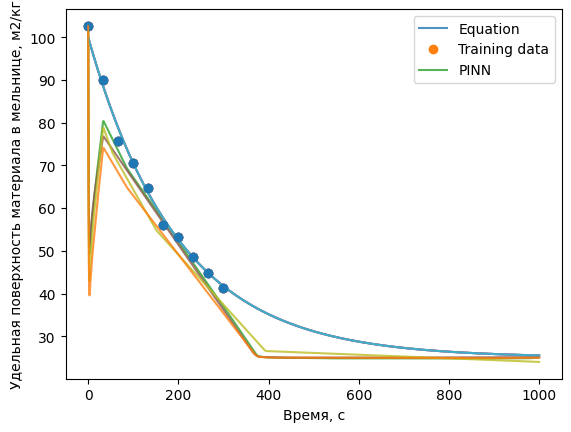

In [38]:
mse = []
ks = []

for i in np.arange(0.5, 0.8, 0.1):
    pinn = Pinn(1, 1, loss2=physics_loss, loss2_weight=1, epochs=40000, lr= 5e-6, k=i).to(DEVICE)

    losses = pinn.fit(t, S)
    l.append(min(losses))
    ks.append(i)
    # plt.plot(losses)
    # plt.yscale('log')

    preds = pinn.predict(times)
    mse_o = np.mean((preds - surfaces)**2)
    mse.append(mse_o)
    print(pinn.k)

    plt.plot(times, surfaces, alpha=0.8)
    plt.plot(t, S, 'o')
    plt.plot(times, preds, alpha=0.8)
    plt.legend(labels=['Equation','Training data', 'PINN'])
    plt.ylabel('Удельная поверхность материала в мельнице, м2/кг')
    plt.xlabel('Время, с')

for z, m in zip(mse, ks):
    print(f'При k = {m} mse = {z}')

In [35]:
for z, m in zip(mse, ks):
    print(f'При k = {m} mse = {z}')

При k = 0.0 mse = 611.781730343595
При k = 0.001 mse = 637.4418397869996
При k = 0.002 mse = 668.4294403467719
При k = 0.003 mse = 659.7309509284427
При k = 0.004 mse = 687.9653681360453
При k = 0.005 mse = 673.7283215608439
При k = 0.006 mse = 693.3198472465689
При k = 0.007 mse = 697.4718182188362
При k = 0.008 mse = 701.444672956703
При k = 0.009000000000000001 mse = 697.269181942659
При k = 0.01 mse = 678.3095642087084
При k = 0.011 mse = 704.0554656075776
При k = 0.012 mse = 726.1502987878102
При k = 0.013000000000000001 mse = 735.32185577528
При k = 0.014 mse = 708.6408652853356
При k = 0.015 mse = 725.6157346235998
При k = 0.016 mse = 718.2290789656757
При k = 0.017 mse = 720.019562017444
При k = 0.018000000000000002 mse = 710.1992820122538
При k = 0.019 mse = 742.2536837795316
При k = 0.02 mse = 702.3310675015169
При k = 0.021 mse = 724.5893032495454
При k = 0.022 mse = 723.0187822466523
При k = 0.023 mse = 730.7997927556781
При k = 0.024 mse = 715.7481744312269
При k = 0.025 m

In [39]:
for z, m in zip(mse, ks):
    print(f'При k = {m} mse = {z}')

При k = 0.5 mse = 639.9415917079646
При k = 0.6 mse = 624.7420526948376
При k = 0.7 mse = 597.89999301908
При k = 0.7999999999999999 mse = 591.621432028392


In [36]:
min(mse)

611.781730343595